# Review Count & Sales 분석

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
data = pd.read_csv("review-rv_sales 1_csv.csv")

In [17]:
data

,yr_month,financial_category,written_avg_rating,written_12_cnt,written_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
0,202212,SmartBases,4.038674,37,181,0.204420,4.512716,73.0,983.0,0.074262,1729285.82,17377
1,202412,Platform Beds,3.854545,103,440,0.234091,3.854545,103.0,440.0,0.234091,4021850.94,40099
2,202309,Toppers,3.106061,31,66,0.469697,4.163462,61.0,416.0,0.146635,240646.93,4615
3,202201,Non Bedroom Furniture,3.853333,19,75,0.253333,NaN,NaN,NaN,NaN,518281.03,4766
4,202411,Others,5.000000,0,2,0.000000,4.833333,0.0,6.0,0.000000,41752.46,1279
...,...,...,...,...,...,...,...,...,...,...,...,...
385,202303,Toppers,2.700637,89,157,0.566879,3.853425,166.0,730.0,0.227397,1018152.28,20058
386,202311,Box Springs,3.840206,49,194,0.252577,4.371156,100.0,943.0,0.106045,4148741.49,31839
387,202202,Box Springs,4.133739,56,329,0.170213,NaN,NaN,NaN,NaN,6632445.72,48676
388,202401,Toppers,3.041667,21,48,0.437500,4.150602,48.0,332.0,0.144578,185152.78,3537


In [27]:
data['yr_month'] = pd.to_datetime(data['yr_month'], format='%Y%m')

In [49]:
monthly_sum = data.groupby(data['yr_month'])[['written_all_cnt','all_all_cnt','sales_amount']].sum().sort_index()
monthly_sum['sales_amount_1000'] = monthly_sum['sales_amount']/1000

In [51]:
monthly_sum

,written_all_cnt,all_all_cnt,sales_amount,sales_amount_1000
yr_month,,,,
2022-01-01,2792,0.0,35594229.47,35594.22947
2022-02-01,2299,0.0,36866385.13,36866.38513
2022-03-01,2765,0.0,45830683.63,45830.68363
2022-04-01,2474,0.0,44995200.89,44995.20089
2022-05-01,2564,39399.0,54699831.61,54699.83161
2022-06-01,2587,22866.0,52863011.18,52863.01118
2022-07-01,2993,32386.0,80077380.17,80077.38017
2022-08-01,3188,28036.0,70360878.78,70360.87878
2022-09-01,2843,25549.0,54948120.49,54948.12049


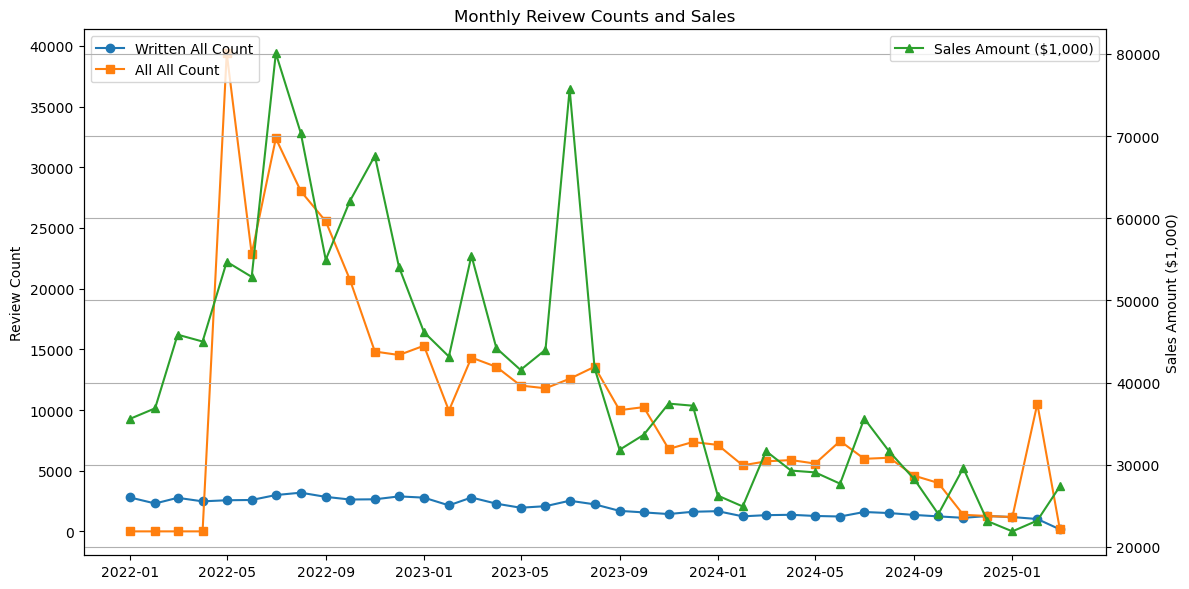

In [55]:
# 그래프 그리기
#plt.figure(figsize=(12,6))
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(monthly_sum.index, monthly_sum['written_all_cnt'], marker='o', label='Written All Count')
ax1.plot(monthly_sum.index, monthly_sum['all_all_cnt'], marker='s', label='All All Count')
ax1.set_ylabel('Review Count')
ax1.tick_params(axis='y')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(monthly_sum.index, monthly_sum['sales_amount_1000'], marker='^', label='Sales Amount ($1,000)', color='tab:green')
ax2.set_ylabel('Sales Amount ($1,000)')
ax2.tick_params(axis='y')
ax2.legend(loc='upper right')

#공통 설정
plt.title('Monthly Reivew Counts and Sales')
plt.xlabel('Year-Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()